# Exploratory Analysis — Key Findings

**Dataset:** 232,679 cleaned sales lines · 147 products · Jan 2021–Sep 2022 · €562,717 total revenue

1. **One product carries the business.** The Traditional Baguette accounts for ~33% of all units sold (118,093) and ~26% of revenue — more than the next four products combined.

2. **Best sellers are not best earners.** Volume and revenue tell different stories: sandwiches (e.g. FORMULE SANDWICH) rank ~9th in units but 2nd in revenue, because they carry a much higher price than a €0.90 baguette. Planning on unit counts alone would undervalue them.

3. **Demand is weekend-heavy.** Sunday is the top day (€126,864) — ~2.5× the lowest genuine trading day. *Validation note:* Wednesday shows the lowest revenue, but this reflects the bakery being closed on most Wednesdays (62 dates vs ~90 for other days), not weak demand.

4. **A repeatable summer peak.** July and August are the strongest months in both 2021 and 2022, confirmed on average revenue *per open day* (~€1,500–1,750/day vs ~€1,000 in spring) — so it's a true seasonal signal, not a counting artifact.

5. **A morning business.** Sales concentrate 8am–noon, peaking at 11am; the afternoon is a fraction of the morning.

**So what (for production planning):** Prioritise baguette availability, treat sandwiches as high-value items worth protecting, scale production up for weekends and summer, and focus output on the morning window.

In [1]:
import pandas as pd

df = pd.read_csv("../data/cleaned/bakery_sales_clean.csv", parse_dates=["datetime"])
print("Rows:", len(df))
df.head()

Rows: 232679


,date,time,ticket_number,article,Quantity,unit_price,datetime,revenue
0,2021-01-02,08:38,150040,BAGUETTE,1.0,0.90,2021-01-02 08:38:00,0.90
1,2021-01-02,08:38,150040,PAIN AU CHOCOLAT,3.0,1.20,2021-01-02 08:38:00,3.60
2,2021-01-02,09:14,150041,PAIN AU CHOCOLAT,2.0,1.20,2021-01-02 09:14:00,2.40
3,2021-01-02,09:14,150041,PAIN,1.0,1.15,2021-01-02 09:14:00,1.15
4,2021-01-02,09:25,150042,TRADITIONAL BAGUETTE,5.0,1.20,2021-01-02 09:25:00,6.00


In [2]:
print("Total revenue:    €", round(df['revenue'].sum(), 2))
print("Total units sold:  ", int(df['Quantity'].sum()))
print("Total transactions: ", df['ticket_number'].nunique())
print("Avg items per ticket:", round(df.groupby('ticket_number')['Quantity'].sum().mean(), 2))
print("Avg ticket value:    €", round(df.groupby('ticket_number')['revenue'].sum().mean(), 2))

Total revenue:    € 562716.7
Total units sold:   362156
Total transactions:  135685
Avg items per ticket: 2.67
Avg ticket value:    € 4.15


In [3]:
df.groupby('article')['Quantity'].sum().sort_values(ascending=False).head(10)

article
TRADITIONAL BAGUETTE    118093.0
CROISSANT                29822.0
PAIN AU CHOCOLAT         25367.0
COUPE                    23601.0
BANETTE                  22870.0
BAGUETTE                 22156.0
CEREAL BAGUETTE           7478.0
SPECIAL BREAD             5488.0
FORMULE SANDWICH          5285.0
TARTELETTE                5051.0
Name: Quantity, dtype: float64

In [4]:
df.groupby('article')['revenue'].sum().sort_values(ascending=False).head(10)

article
TRADITIONAL BAGUETTE    145533.75
FORMULE SANDWICH         35419.50
CROISSANT                33770.45
PAIN AU CHOCOLAT         31262.15
BANETTE                  24704.30
BAGUETTE                 20578.20
SANDWICH COMPLET         13659.50
SPECIAL BREAD            13498.60
TRAITEUR                 12368.40
GRAND FAR BRETON         10786.00
Name: revenue, dtype: float64

In [5]:
order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
df['day_of_week'] = df['datetime'].dt.day_name()
df.groupby('day_of_week')['revenue'].sum().reindex(order)

day_of_week
Monday        74539.40
Tuesday       67896.90
Wednesday     50437.40
Thursday      70721.73
Friday        77745.82
Saturday      94511.92
Sunday       126863.53
Name: revenue, dtype: float64

In [6]:
df['month'] = df['datetime'].dt.to_period('M')
df.groupby('month')['revenue'].sum().sort_values(ascending=False).head(6)

month
2022-08    54044.10
2021-08    48854.05
2022-07    47026.57
2021-07    42334.10
2022-05    29837.65
2021-05    29705.65
Freq: M, Name: revenue, dtype: float64

In [7]:
df['hour'] = df['datetime'].dt.hour
df.groupby('hour')['Quantity'].sum().sort_values(ascending=False).head(6)

hour
11    69552.0
10    64820.0
9     57874.0
12    52580.0
8     50659.0
17    16249.0
Name: Quantity, dtype: float64

In [8]:
# Count how many of each weekday actually appear in the data
df['date_only'] = df['datetime'].dt.date
days_present = df.drop_duplicates('date_only')['datetime'].dt.day_name().value_counts()
print("Number of each weekday in the dataset:")
print(days_present.reindex(order))

Number of each weekday in the dataset:
datetime
Monday       88
Tuesday      89
Wednesday    62
Thursday     89
Friday       91
Saturday     90
Sunday       91
Name: count, dtype: int64


In [9]:
# Average daily revenue per month — fair comparison regardless of days present
monthly_avg = df.groupby('month').agg(
    total_revenue=('revenue','sum'),
    days=('date_only','nunique')
)
monthly_avg['avg_per_day'] = monthly_avg['total_revenue'] / monthly_avg['days']
monthly_avg.sort_values('avg_per_day', ascending=False).head(6)

,total_revenue,days,avg_per_day
month,,,
2022-08,54044.10,31,1743.358065
2021-08,48854.05,31,1575.937097
2022-07,47026.57,31,1516.986129
2021-07,42334.10,31,1365.616129
2021-05,29705.65,27,1100.209259
2022-05,29837.65,30,994.588333


In [10]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

NAVY = "#1f3a5f"
plt.rcParams.update({"figure.dpi": 110, "font.size": 11,
                     "axes.spines.top": False, "axes.spines.right": False})
comma = mticker.FuncFormatter(lambda x, _: f"{int(x):,}")

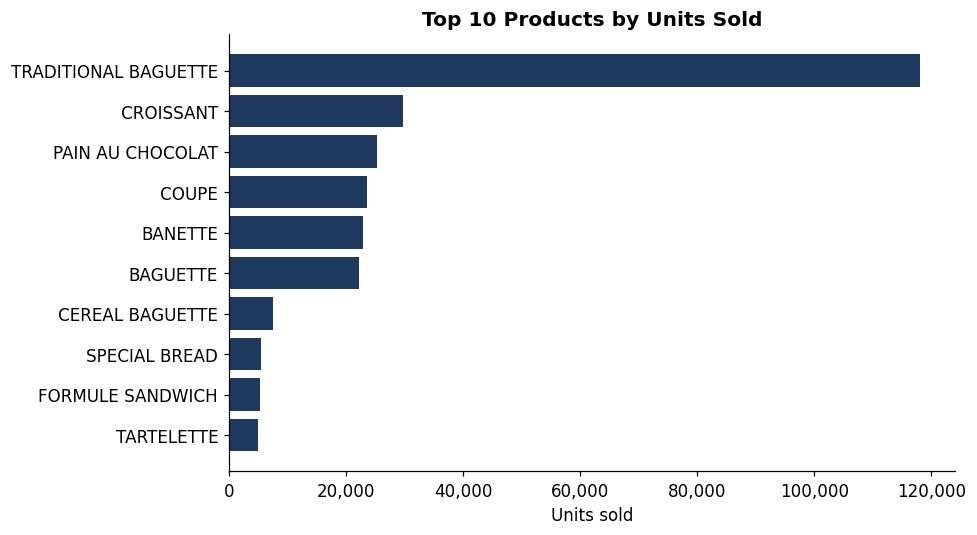

In [11]:
top_units = df.groupby("article")["Quantity"].sum().sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(top_units.index[::-1], top_units.values[::-1], color=NAVY)
ax.set_title("Top 10 Products by Units Sold", fontweight="bold")
ax.set_xlabel("Units sold"); ax.xaxis.set_major_formatter(comma)
plt.tight_layout()
plt.savefig("../images/charts/01_top_products_units.png")
plt.show()

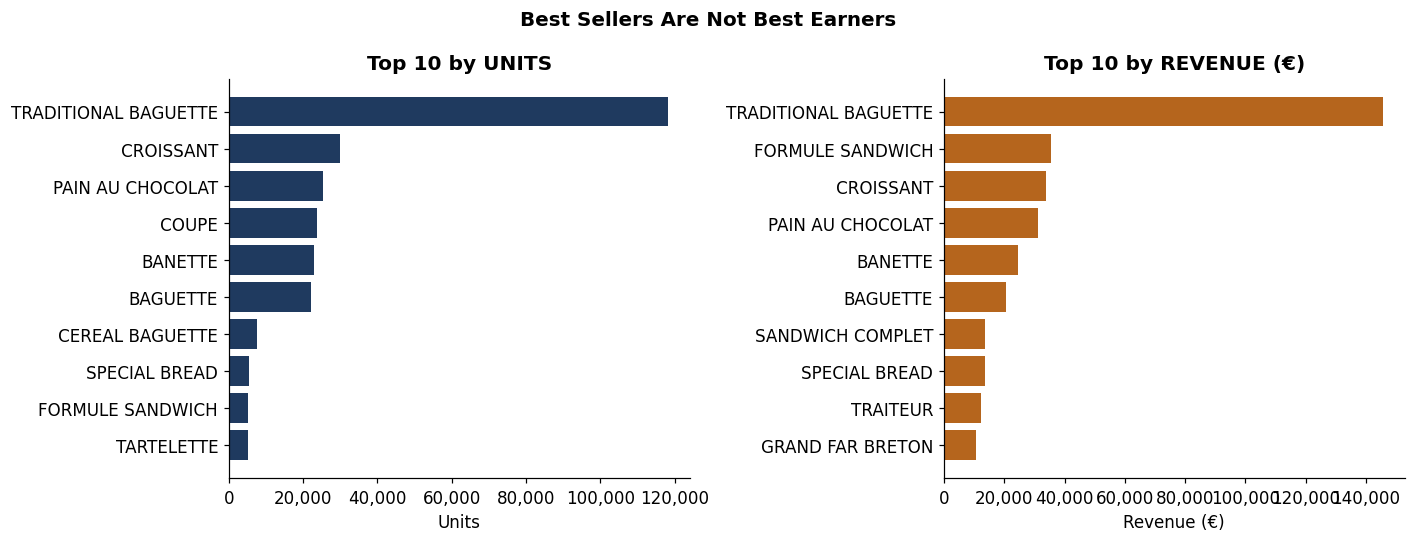

In [12]:
top_rev = df.groupby("article")["revenue"].sum().sort_values(ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].barh(top_units.index[::-1], top_units.values[::-1], color=NAVY)
axes[0].set_title("Top 10 by UNITS", fontweight="bold"); axes[0].set_xlabel("Units")
axes[1].barh(top_rev.index[::-1], top_rev.values[::-1], color="#b5651d")
axes[1].set_title("Top 10 by REVENUE (€)", fontweight="bold"); axes[1].set_xlabel("Revenue (€)")
for a in axes: a.xaxis.set_major_formatter(comma)
fig.suptitle("Best Sellers Are Not Best Earners", fontweight="bold", fontsize=13)
plt.tight_layout()
plt.savefig("../images/charts/02_units_vs_revenue.png")
plt.show()

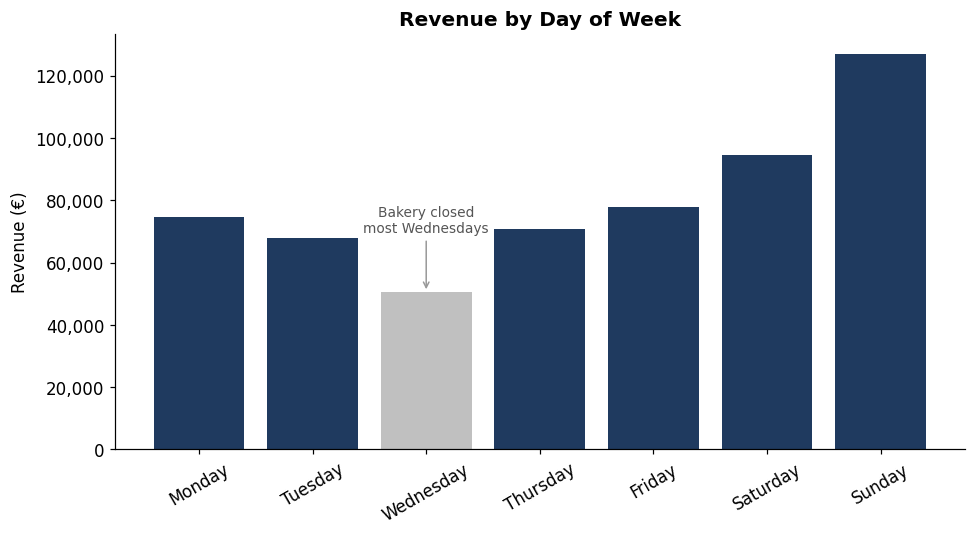

In [13]:
dow = df.groupby("day_of_week")["revenue"].sum().reindex(order)
colors = [NAVY]*7; colors[2] = "#c0c0c0"   # grey out Wednesday

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(dow.index, dow.values, color=colors)
ax.set_title("Revenue by Day of Week", fontweight="bold")
ax.set_ylabel("Revenue (€)"); ax.yaxis.set_major_formatter(comma)
ax.annotate("Bakery closed\nmost Wednesdays", xy=(2, dow["Wednesday"]),
            xytext=(2, dow.max()*0.55), ha="center", fontsize=9, color="#555",
            arrowprops=dict(arrowstyle="->", color="#999"))
plt.xticks(rotation=30); plt.tight_layout()
plt.savefig("../images/charts/03_revenue_by_day.png")
plt.show()

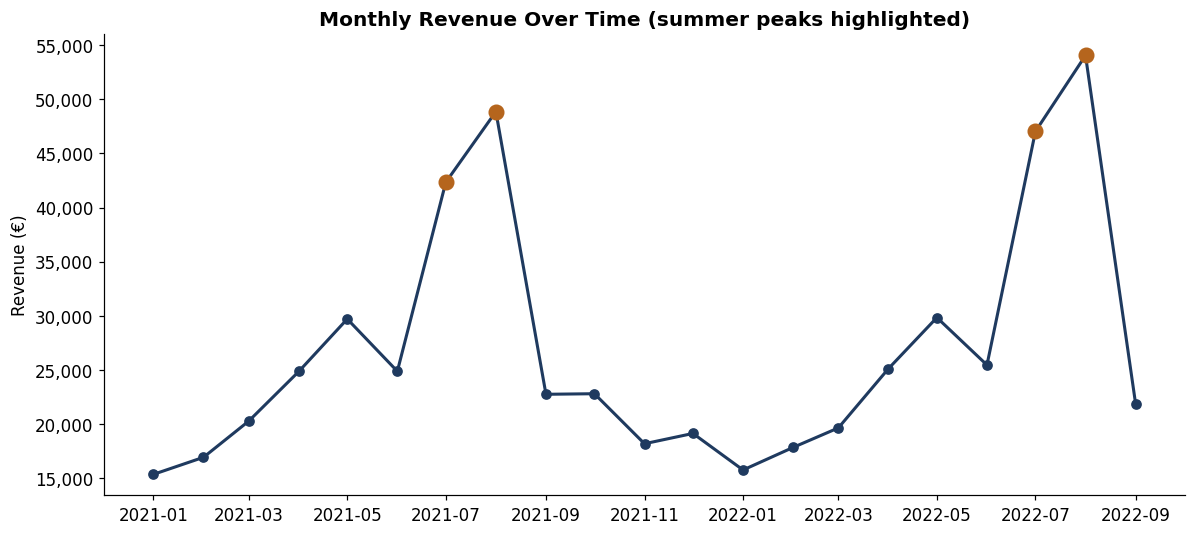

In [14]:
monthly = df.groupby(df["datetime"].dt.to_period("M").dt.to_timestamp())["revenue"].sum()

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(monthly.index, monthly.values, marker="o", color=NAVY, linewidth=2)
for m, v in monthly.items():
    if m.month in (7, 8):
        ax.scatter([m], [v], color="#b5651d", s=90, zorder=5)  # highlight summer
ax.set_title("Monthly Revenue Over Time (summer peaks highlighted)", fontweight="bold")
ax.set_ylabel("Revenue (€)"); ax.yaxis.set_major_formatter(comma)
plt.tight_layout()
plt.savefig("../images/charts/04_monthly_trend.png")
plt.show()